# ChatBS Base Results Analysis

This notebook analyzes the CSV outputs in `analysis/` for the ChatBS base evaluation. It loads the bool/entity/numeric result tables, identifies examples where baselines beat `ours`, and visualizes pairwise win rates against `fullcontext`, `llmbased`, and `grasp`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 240)

NOTEBOOK_DIR = Path.cwd()
ANALYSIS_DIR = NOTEBOOK_DIR / "analysis"
if not ANALYSIS_DIR.exists():
    ANALYSIS_DIR = Path("evaluations/chatbs-base/analysis")

ANALYSIS_DIR.resolve()

PosixPath('/home/desild/work/research/LLM-Workflow-Explorer/evaluations/chatbs-base/analysis')

## 1. Load Evaluation DataFrames

In [2]:
TASKS = ["bool", "entity", "numeric"]

results = {
    task: pd.read_csv(ANALYSIS_DIR / task / "results.csv")
    for task in TASKS
}
summaries = {
    task: pd.read_csv(ANALYSIS_DIR / task / "results_summary.csv")
    for task in TASKS
}
pairwise = pd.read_csv(ANALYSIS_DIR / "answer_winrate" / "pairwise_answer_winrate.csv")
winrate_summary = pd.read_csv(ANALYSIS_DIR / "answer_winrate" / "answer_winrate_summary.csv")

for task, df in results.items():
    print(f"{task:>7}: {df.shape[0]} rows x {df.shape[1]} columns | runs={sorted(df['run'].dropna().unique())}")
print(f"pairwise: {pairwise.shape[0]} rows x {pairwise.shape[1]} columns")

   bool: 152 rows x 31 columns | runs=['fullcontext', 'grasp', 'llmbased', 'ours']
 entity: 196 rows x 40 columns | runs=['fullcontext', 'grasp', 'llmbased', 'ours']
numeric: 64 rows x 31 columns | runs=['fullcontext', 'grasp', 'llmbased', 'ours']
pairwise: 309 rows x 13 columns


In [3]:
summary_tables = []
for task, df in summaries.items():
    tmp = df.copy()
    tmp.insert(0, "task", task)
    summary_tables.append(tmp)

combined_summary = pd.concat(summary_tables, ignore_index=True)
combined_summary

,task,run,evaluated_examples,matched_ground_truth,avg_prediction_time_taken,answer_token_precision_mean,answer_token_precision_std,answer_token_recall_mean,answer_token_recall_std,answer_token_f1_mean,answer_token_f1_std,gt_entity_total_mean,gt_entity_total_std,gt_entity_covered_mean,gt_entity_covered_std,gt_entity_coverage_mean,gt_entity_coverage_std,bertscore_precision_mean,bertscore_precision_std,bertscore_recall_mean,bertscore_recall_std,bertscore_f1_mean,bertscore_f1_std,nli_entailment_max_mean,nli_entailment_max_std,nli_pairs_scored_mean,nli_pairs_scored_std,bool_accuracy_mean,bool_accuracy_std,entity_gt_total_mean,entity_gt_total_std,entity_retrieved_final_total_mean,entity_retrieved_final_total_std,entity_retrieved_total_total_mean,entity_retrieved_total_total_std,entity_recall_final_mean,entity_recall_final_std,entity_precision_final_mean,entity_precision_final_std,entity_f1_final_mean,entity_f1_final_std,entity_recall_total_mean,entity_recall_total_std,entity_precision_total_mean,entity_precision_total_std,entity_f1_total_mean,entity_f1_total_std,numeric_ground_truth_count_mean,numeric_ground_truth_count_std,numeric_predicted_count_mean,numeric_predicted_count_std,numeric_accuracy_mean,numeric_accuracy_std
0,bool,fullcontext,38,38,18.636609,0.645068,0.213839,0.476978,0.209112,0.502966,0.185945,2.289474,2.759827,0.394737,0.679406,0.146592,0.277779,0.809709,0.026996,0.836885,0.034411,0.822584,0.023401,0.632921,0.277266,1.00000,0.000000,0.894737,0.311012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,bool,grasp,38,38,15.282982,0.109508,0.246642,0.096716,0.200959,0.087578,0.185844,2.289474,2.759827,0.026316,0.162221,0.002024,0.012479,0.842669,0.052745,0.767199,0.061134,0.801240,0.040776,0.491125,0.344054,0.50000,0.506712,0.289474,0.459606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,bool,llmbased,38,38,0.454403,0.348037,0.173975,0.169571,0.067530,0.208698,0.077780,2.289474,2.759827,0.000000,0.000000,0.000000,0.000000,0.782562,0.027832,0.776928,0.018061,0.779326,0.014747,0.271990,0.331518,1.00000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,bool,ours,38,38,38.228725,0.113525,0.031328,0.847187,0.182710,0.197100,0.049470,2.289474,2.759827,0.210526,0.413155,0.153340,0.345821,0.796221,0.018376,0.863399,0.027422,0.828318,0.020515,0.341247,0.240152,1.00000,0.000000,0.605263,0.495355,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,entity,fullcontext,49,49,17.327311,0.410788,0.241046,0.285679,0.212815,0.250947,0.142217,2.673469,3.118411,0.428571,0.540062,0.350775,0.430162,0.834320,0.063568,0.843308,0.061540,0.838256,0.059388,0.312391,0.258355,1.00000,0.000000,NaN,NaN,2.55102,3.075855,6.857143,3.452053,11.142857,4.276876,0.566949,0.441061,0.160490,0.169350,0.379824,0.152705,0.658386,0.443409,0.112145,0.130628,0.268076,0.168961,NaN,NaN,NaN,NaN,NaN,NaN
5,entity,grasp,49,49,16.038171,0.185071,0.260656,0.112896,0.180168,0.097409,0.136544,2.673469,3.118411,0.122449,0.484452,0.044574,0.174753,0.826873,0.036846,0.786379,0.033763,0.805467,0.026610,0.259760,0.257020,0.55102,0.502545,NaN,NaN,2.55102,3.075855,0.469388,1.276421,0.469388,1.276421,0.027132,0.125621,0.175000,0.361544,0.583333,0.117851,0.027132,0.125621,0.175000,0.361544,0.583333,0.117851,NaN,NaN,NaN,NaN,NaN,NaN
6,entity,llmbased,49,49,0.447434,0.332315,0.191466,0.131570,0.115785,0.133649,0.099032,2.673469,3.118411,0.020408,0.142857,0.002326,0.015250,0.789192,0.024967,0.779197,0.027025,0.783626,0.015767,0.149480,0.181747,1.00000,0.000000,NaN,NaN,2.55102,3.075855,8.224490,5.734636,10.632653,4.965271,0.252462,0.343042,0.041346,0.059016,0.162521,0.078137,0.527010,0.409608,0.088388,0.079374,0.200143,0.090508,NaN,NaN,NaN,NaN,NaN,NaN
7,entity,ours,49,49,39.572817,0.118917,0.088536,0.547813,0.246176,0.156258,0.089507,2.673469,3.118411,0.571429,1.848423,0.11

## 2. Examples Where Baselines Are Right But Ours Is Wrong

For bool and numeric tasks, correctness is defined by exact `*_accuracy == 1`. For entity tasks, this notebook uses the LLM judge pairwise scores: an example is flagged when both `llmbased` and `fullcontext` have a higher average judge score than `ours` for the same `ground_truth_id`.

In [4]:
def metric_pivot(task: str, metric: str) -> pd.DataFrame:
    df = results[task].copy()
    df[metric] = pd.to_numeric(df[metric], errors="coerce")
    return df.pivot_table(
        index="ground_truth_id",
        columns="run",
        values=metric,
        aggfunc="mean",
    )


def answer_pivot(task: str) -> pd.DataFrame:
    return results[task].pivot_table(
        index="ground_truth_id",
        columns="run",
        values="pred_answer",
        aggfunc="first",
    ).add_prefix("answer_")


def question_frame(task: str) -> pd.DataFrame:
    return (
        results[task]
        .drop_duplicates("ground_truth_id")[["ground_truth_id", "question", "ground_truth_answer", "ground_truth_qtype"]]
        .set_index("ground_truth_id")
    )


def baseline_right_ours_wrong(task: str, metric: str) -> pd.DataFrame:
    scores = metric_pivot(task, metric)
    required = {"ours", "fullcontext", "llmbased"}
    missing = required - set(scores.columns)
    if missing:
        raise ValueError(f"Missing runs for {task}: {sorted(missing)}")

    mask = (
        scores["fullcontext"].eq(1)
        & scores["llmbased"].eq(1)
        & scores["ours"].fillna(0).lt(1)
    )
    out = (
        question_frame(task)
        .join(scores.add_suffix(f"_{metric}"))
        .join(answer_pivot(task))
        .loc[mask]
        .reset_index()
        .sort_values("ground_truth_id", key=lambda s: s.str.extract(r"(\d+)", expand=False).astype(int))
    )
    return out


bool_baselines_right_ours_wrong = baseline_right_ours_wrong("bool", "bool_accuracy")
numeric_baselines_right_ours_wrong = baseline_right_ours_wrong("numeric", "numeric_accuracy")

print("Bool examples:", len(bool_baselines_right_ours_wrong))
print("Numeric examples:", len(numeric_baselines_right_ours_wrong))

Bool examples: 0
Numeric examples: 0


In [5]:
bool_baselines_right_ours_wrong[[
    "ground_truth_id", "question", "ground_truth_answer",
    "fullcontext_bool_accuracy", "llmbased_bool_accuracy", "ours_bool_accuracy",
    "answer_fullcontext", "answer_llmbased", "answer_ours",
]]

,ground_truth_id,question,ground_truth_answer,fullcontext_bool_accuracy,llmbased_bool_accuracy,ours_bool_accuracy,answer_fullcontext,answer_llmbased,answer_ours


In [6]:
numeric_baselines_right_ours_wrong[[
    "ground_truth_id", "question", "ground_truth_answer",
    "fullcontext_numeric_accuracy", "llmbased_numeric_accuracy", "ours_numeric_accuracy",
    "answer_fullcontext", "answer_llmbased", "answer_ours",
]]

,ground_truth_id,question,ground_truth_answer,fullcontext_numeric_accuracy,llmbased_numeric_accuracy,ours_numeric_accuracy,answer_fullcontext,answer_llmbased,answer_ours


In [7]:
entity_pairwise = pairwise[pairwise["ground_truth_qtype"].str.contains("entity", na=False)].copy()
score_rows = []
for _, row in entity_pairwise.iterrows():
    score_rows.append({
        "ground_truth_id": row["ground_truth_id"],
        "method": row["method_a"],
        "llm_score": row["method_a_score"],
    })
    score_rows.append({
        "ground_truth_id": row["ground_truth_id"],
        "method": row["method_b"],
        "llm_score": row["method_b_score"],
    })

entity_scores_long = pd.DataFrame(score_rows)
entity_scores_long["llm_score"] = pd.to_numeric(entity_scores_long["llm_score"], errors="coerce")
entity_scores = entity_scores_long.pivot_table(
    index="ground_truth_id",
    columns="method",
    values="llm_score",
    aggfunc="mean",
)

entity_mask = (
    entity_scores["fullcontext"].gt(entity_scores["ours"])
    & entity_scores["llmbased"].gt(entity_scores["ours"])
)

entity_baselines_higher_ours_lower = (
    question_frame("entity")
    .join(entity_scores.add_suffix("_avg_llm_score"))
    .join(answer_pivot("entity"))
    .loc[entity_mask]
    .reset_index()
    .sort_values("ground_truth_id", key=lambda s: s.str.extract(r"(\d+)", expand=False).astype(int))
)

print("Entity examples:", len(entity_baselines_higher_ours_lower))
entity_baselines_higher_ours_lower[[
    "ground_truth_id", "question", "ground_truth_answer",
    "fullcontext_avg_llm_score", "llmbased_avg_llm_score", "ours_avg_llm_score",
    "answer_fullcontext", "answer_llmbased", "answer_ours",
]]

Entity examples: 1


,ground_truth_id,question,ground_truth_answer,fullcontext_avg_llm_score,llmbased_avg_llm_score,ours_avg_llm_score,answer_fullcontext,answer_llmbased,answer_ours
0,gt_8,\nwhat are the input parameters of the function used in system prompt template step in the pipeline?\n,\n The input parameters to system prompt template function.\n\n Funtion name | Function returns\nSystem Prompt Template Generator@en^^<xsd:string> | Input port for age@en^^<xsd:string>\nSystem Prompt Template Generator@en^^<xsd:st...,1.0,1.0,0.0,"The system prompt template function receives eight input parameters: age, allergies, bodyMassIndex, diagnosis, foodPreferences, gender, height and weight.","The System Prompt Template Generator execution (system prompt execution 1 1) ran with inputs age, allergies, bodyMassIndex, diagnosis, foodPreferences, gender, height, weight and produced system prompt.",User Question: what are the input parameters of the function used in system prompt template step in the pipeline? Trace Answers Question: what are the input parameters of the function used in system prompt template step in the pipeline?...


### Compact `gt_id` Lists

In [8]:
hard_case_ids = {
    "bool": bool_baselines_right_ours_wrong["ground_truth_id"].tolist(),
    "entity": entity_baselines_higher_ours_lower["ground_truth_id"].tolist(),
    "numeric": numeric_baselines_right_ours_wrong["ground_truth_id"].tolist(),
}
hard_case_ids

{'bool': [], 'entity': ['gt_8'], 'numeric': []}

## 3. Pairwise Win Rate: Ours vs Baselines

In [9]:
def pairwise_ours_summary(pairwise_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    ours_rows = pairwise_df[(pairwise_df["method_a"].eq("ours")) | (pairwise_df["method_b"].eq("ours"))].copy()
    for opponent, grp in ours_rows.groupby(
        ours_rows.apply(lambda r: r["method_b"] if r["method_a"] == "ours" else r["method_a"], axis=1)
    ):
        total = len(grp)
        ours_wins = grp["winning_method"].eq("ours").sum()
        opponent_wins = grp["winning_method"].eq(opponent).sum()
        ties = total - ours_wins - opponent_wins
        rows.append({
            "opponent": opponent,
            "comparisons": total,
            "ours_wins": int(ours_wins),
            "opponent_wins": int(opponent_wins),
            "ties": int(ties),
            "ours_winrate": (ours_wins + 0.5 * ties) / total if total else float("nan"),
            "opponent_winrate": (opponent_wins + 0.5 * ties) / total if total else float("nan"),
        })
    order = ["fullcontext", "llmbased", "grasp"]
    return pd.DataFrame(rows).assign(
        opponent=lambda d: pd.Categorical(d["opponent"], categories=order, ordered=True)
    ).sort_values("opponent").reset_index(drop=True)


ours_vs_baselines = pairwise_ours_summary(pairwise)
ours_vs_baselines

,opponent,comparisons,ours_wins,opponent_wins,ties,ours_winrate,opponent_winrate
0,fullcontext,103,54,49,0,0.524272,0.475728
1,llmbased,103,95,8,0,0.922330,0.077670
2,grasp,103,93,10,0,0.902913,0.097087


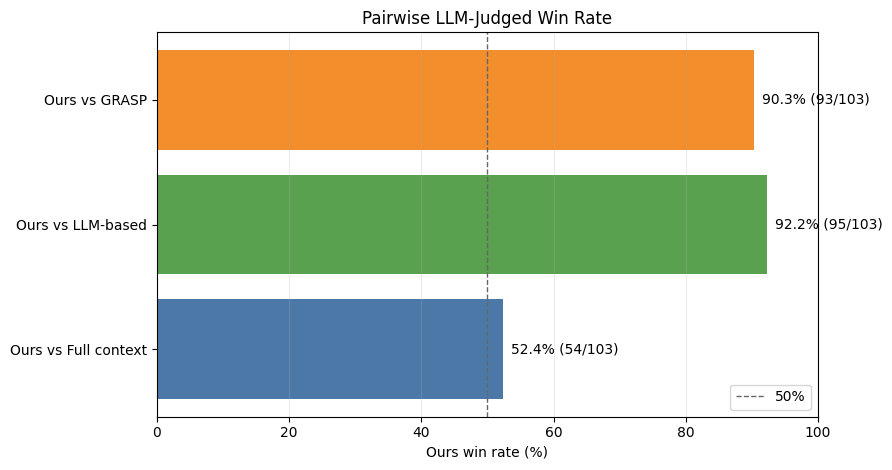

In [10]:
labels = {
    "fullcontext": "Full context",
    "llmbased": "LLM-based",
    "grasp": "GRASP",
}

plot_df = ours_vs_baselines.copy()
plot_df["comparison"] = plot_df["opponent"].astype(str).map(lambda x: f"Ours vs {labels.get(x, x)}")
plot_df["ours_winrate_pct"] = plot_df["ours_winrate"] * 100

fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.barh(
    plot_df["comparison"],
    plot_df["ours_winrate_pct"],
    color=["#4C78A8", "#59A14F", "#F28E2B"],
)
ax.axvline(50, color="#666666", linestyle="--", linewidth=1, label="50%")
ax.set_xlim(0, 100)
ax.set_xlabel("Ours win rate (%)")
ax.set_title("Pairwise LLM-Judged Win Rate")
ax.grid(axis="x", alpha=0.25)

for bar, (_, row) in zip(bars, plot_df.iterrows()):
    ax.text(
        min(bar.get_width() + 1.2, 96),
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f}% ({row['ours_wins']}/{row['comparisons']})",
        va="center",
        fontsize=10,
    )

ax.legend(loc="lower right")
plt.tight_layout()

### Optional: Win Rate by Question Type

In [11]:
by_qtype = []
for qtype, grp in pairwise.groupby("ground_truth_qtype"):
    tmp = pairwise_ours_summary(grp)
    tmp.insert(0, "ground_truth_qtype", qtype)
    by_qtype.append(tmp)

ours_vs_baselines_by_qtype = pd.concat(by_qtype, ignore_index=True)
ours_vs_baselines_by_qtype

,ground_truth_qtype,opponent,comparisons,ours_wins,opponent_wins,ties,ours_winrate,opponent_winrate
0,"[""multi"", ""entity""]",fullcontext,37,19,18,0,0.513514,0.486486
1,"[""multi"", ""entity""]",llmbased,37,36,1,0,0.972973,0.027027
2,"[""multi"", ""entity""]",grasp,37,35,2,0,0.945946,0.054054
3,"[""multi"", ""numeric""]",fullcontext,16,12,4,0,0.750000,0.250000
4,"[""multi"", ""numeric""]",llmbased,16,15,1,0,0.937500,0.062500
5,"[""multi"", ""numeric""]",grasp,16,16,0,0,1.000000,0.000000
6,"[""single"", ""bool""]",fullcontext,38,20,18,0,0.526316,0.473684
7,"[""single"", ""bool""]",llmbased,38,33,5,0,0.868421,0.131579
8,"[""single"", ""bool""]",grasp,38,31,7,0,0.815789,0.184211
9,"[""single"", ""entity""]",fullcontext,12,3,9,0,0.250000,0.750000


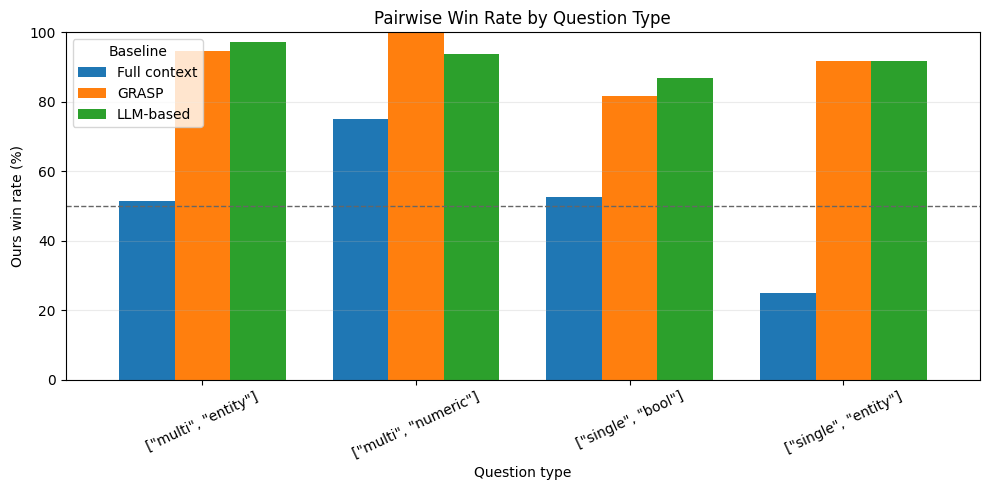

In [12]:
plot_qtype = ours_vs_baselines_by_qtype.copy()
plot_qtype["opponent"] = plot_qtype["opponent"].astype(str).map(labels)
plot_qtype["ours_winrate_pct"] = plot_qtype["ours_winrate"] * 100

ax = plot_qtype.pivot(index="ground_truth_qtype", columns="opponent", values="ours_winrate_pct").plot(
    kind="bar",
    figsize=(10, 5),
    rot=25,
    width=0.78,
)
ax.axhline(50, color="#666666", linestyle="--", linewidth=1)
ax.set_ylim(0, 100)
ax.set_ylabel("Ours win rate (%)")
ax.set_xlabel("Question type")
ax.set_title("Pairwise Win Rate by Question Type")
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Baseline")
plt.tight_layout()